
![](../images/35_vae_visualizer/thumbnail.png)

:::{.callout-note appearance="simple"} 
Thanks to [Jonothan Whitaker](https://www.johnowhitaker.com/)'s [VAE implementation](https://github.com/fastai/diffusion-nbs/blob/master/stable_diffusion.ipynb) in [lesson 9a](https://www.youtube.com/watch?v=0_BBRNYInx8) of the fastai course.
:::

This notebook is the source code for a VAE visualization app I created that allows you to see how the compressed latents look like, and tweak certain parameters that produce the latents. You can explore the app [here](https://the-vae-visualizer.solveit.pub/). Works best with images whose dimensions are multiples of 8.

## Explore the VAE

In [ ]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

/usr/local/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [ ]:
!curl --output macaw.jpg 'https://lafeber.com/pet-birds/wp-content/uploads/2018/06/Scarlet-Macaw-2.jpg'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100 58602  100 58602    0     0  1014k      0 --:--:-- --:--:-- --:--:-- 1021k


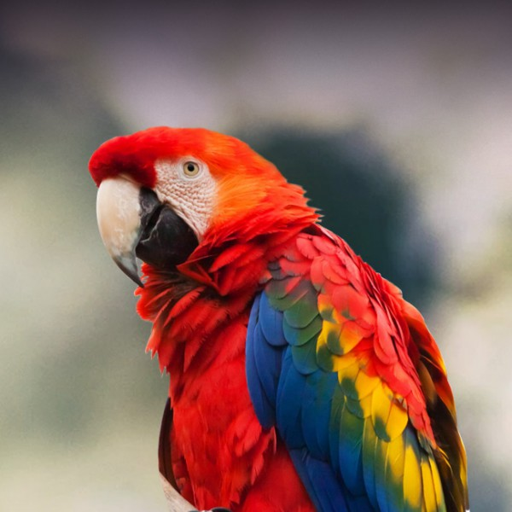

In [ ]:
from PIL import Image
img = Image.open('macaw.jpg').resize((512,512)); img

The image needs to be converted to a PyTorch tensor.

In [ ]:
import torch
from torchvision.transforms import v2
v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])(img)

Image([[[0.1804, 0.1804, 0.1804,  ..., 0.2392, 0.2392, 0.2431],
        [0.1843, 0.1843, 0.1843,  ..., 0.2392, 0.2392, 0.2431],
        [0.1843, 0.1882, 0.1882,  ..., 0.2431, 0.2431, 0.2431],
        ...,
        [0.8471, 0.8471, 0.8471,  ..., 0.5373, 0.5490, 0.5686],
        [0.8471, 0.8471, 0.8471,  ..., 0.5333, 0.5451, 0.5608],
        [0.8471, 0.8471, 0.8471,  ..., 0.5294, 0.5451, 0.5569]],

       [[0.1529, 0.1529, 0.1529,  ..., 0.2118, 0.2118, 0.2157],
        [0.1569, 0.1569, 0.1569,  ..., 0.2118, 0.2118, 0.2157],
        [0.1569, 0.1608, 0.1608,  ..., 0.2157, 0.2157, 0.2157],
        ...,
        [0.8196, 0.8196, 0.8196,  ..., 0.5569, 0.5647, 0.5843],
        [0.8196, 0.8196, 0.8196,  ..., 0.5569, 0.5647, 0.5765],
        [0.8196, 0.8196, 0.8196,  ..., 0.5529, 0.5608, 0.5725]],

       [[0.1843, 0.1843, 0.1843,  ..., 0.2431, 0.2431, 0.2471],
        [0.1882, 0.1882, 0.1882,  ..., 0.2431, 0.2431, 0.2471],
        [0.1882, 0.1922, 0.1922,  ..., 0.2471, 0.2471, 0.2471],
        ..

In [ ]:
ToTensor = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]); ToTensor

Compose(
      ToImage()
      ToDtype(scale=True)
)

In [ ]:
ToTensor(img).shape, ToTensor(img)[None,...].shape

(torch.Size([3, 512, 512]), torch.Size([1, 3, 512, 512]))

`v2.ToDtype` needs to be usedd. Otherwise directly using `v2.ToImage` results in a `uint8` tensor

In [ ]:
import torch
from torchvision.transforms import v2
with torch.no_grad():
    lat = vae.encode(ToTensor(img)[None,...]*2-1)
    lat = 0.18215 * lat.latent_dist.sample()

In [ ]:
lat.shape, lat[0].shape

(torch.Size([1, 4, 64, 64]), torch.Size([4, 64, 64]))

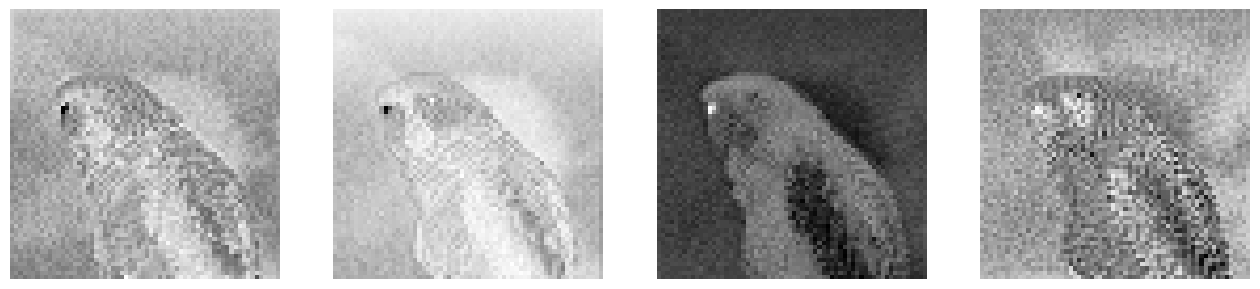

In [ ]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(1,4, figsize=(16,4))
for c in range(4): 
    axs[c].imshow(lat[0][c], cmap='Greys')
    axs[c].axis('off')

## APP

The app will be written with FastHTML. I will be previewing the app inline within this dialog. For this to work, I first tweak a Starlette setting so cookies also work within the inline previews.

In [ ]:
from starlette.middleware.sessions import SessionMiddleware

class PartitionedSessionMiddleware(SessionMiddleware):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.security_flags += "; partitioned"

Now I define the app.

In [ ]:
from fasthtml.common import *

app = FastHTML(hdrs=(picolink, MarkdownJS(), HighlightJS()), debug=True, session_cookie='vae_app', same_site='none', sess_https_only=True, sess_cls=PartitionedSessionMiddleware)
rt = app.route

Now I write the code that will allow me to preview the app inline.

In [ ]:
from functools import partial
from fasthtml.jupyter import *

port = 8002
url = 'the-vae-visualizer.solveit.pub'
server = JupyUvi(app, port=port)

In [ ]:
def get_preview(app): return partial(HTMX, app=app, host=url, port=443)
prev = get_preview(app); prev()

HTML(<iframe src="https://the-vae-visualizer.solveit.pub:443/" style="width: 100%; height: auto; border: none;" onload="{
        let frame = this;
        window.addEventListener('message', function(e) {
            if (e.source !== frame.contentWindow) return; // Only proceed if the message is from this iframe
            if (e.data.height) frame.style.height = (e.data.height+1) + 'px';
        }, false);
    }" allow="accelerometer; autoplay; camera; clipboard-read; clipboard-write; display-capture; encrypted-media; fullscreen; gamepad; geolocation; gyroscope; hid; identity-credentials-get; idle-detection; magnetometer; microphone; midi; payment; picture-in-picture; publickey-credentials-get; screen-wake-lock; serial; usb; web-share; xr-spatial-tracking"></iframe> )

In [ ]:
def p(component):
    if hasattr(component, 'app'): return prev(component)
    else:
        @rt
        def _test(): return component
        return prev(_test)
p(Input())

HTML(<iframe srcdoc="&lt;!doctype html&gt;
&lt;html&gt;
  &lt;head&gt;
    &lt;title&gt;FastHTML page&lt;/title&gt;
    &lt;link rel=&quot;canonical&quot; href=&quot;https://testserver/_L_q6hOucRUKvonFqP8SMzg&quot;&gt;
    &lt;meta charset=&quot;utf-8&quot;&gt;
    &lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1, viewport-fit=cover&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/npm/htmx.org@2.0.7/dist/htmx.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/fasthtml-js@1.0.12/fasthtml.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/surreal@main/surreal.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/gnat/css-scope-inline@main/script.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/npm/@picocss/pico@latest/css/pico.min.css&quot;&gt;
    &lt;style&gt;:root { --pico-font-size: 100%; }&lt;/style&gt;
&lt;script type=&quot;module&quot;&gt;import { marked } from &quot;https://cdn.jsdelivr.net/npm/marked/lib/marked.esm.js&quot;;
proc_htmx(&#x27;.marked&#x27;, e =&gt; e.innerHTML = marked.parse(e.textContent));&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-dark.css&quot; media=&quot;(prefers-color-scheme: dark)&quot;&gt;
    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-light.css&quot; media=&quot;(prefers-color-scheme: light)&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/highlight.min.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.css&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/languages/python.min.js&quot;&gt;&lt;/script&gt;&lt;script type=&quot;module&quot;&gt;
hljs.addPlugin(new CopyButtonPlugin());
hljs.configure({&#x27;cssSelector&#x27;: &#x27;pre code:not([data-highlighted=&quot;yes&quot;])&#x27;});
htmx.onLoad(hljs.highlightAll);&lt;/script&gt;&lt;script&gt;
    function sendmsg() {
        window.parent.postMessage({height: document.documentElement.offsetHeight}, &#x27;*&#x27;);
    }
    window.onload = function() {
        sendmsg();
        document.body.addEventListener(&#x27;htmx:afterSettle&#x27;,    sendmsg);
        document.body.addEventListener(&#x27;htmx:wsAfterMessage&#x27;, sendmsg);
    };&lt;/script&gt;  &lt;/head&gt;
  &lt;body&gt;
    &lt;input&gt;
  &lt;/body&gt;
&lt;/html&gt;
" style="width: 100%; height: auto; border: none;" onload="{
        let frame = this;
        window.addEventListener('message', function(e) {
            if (e.source !== frame.contentWindow) return; // Only proceed if the message is from this iframe
            if (e.data.height) frame.style.height = (e.data.height+1) + 'px';
        }, false);
    }" allow="accelerometer; autoplay; camera; clipboard-read; clipboard-write; display-capture; encrypted-media; fullscreen; gamepad; geolocation; gyroscope; hid; identity-credentials-get; idle-detection; magnetometer; microphone; midi; payment; picture-in-picture; publickey-credentials-get; screen-wake-lock; serial; usb; web-share; xr-spatial-tracking"></iframe> )

In [ ]:
render_ft()

`render_ft` enables rendering of HTML components inline.

### Localization

In [ ]:
from contextvars import ContextVar
current_lang = ContextVar('lang', default='zh'); current_lang

<ContextVar name='lang' default='zh' at 0x75bbc4baab10>

When a user accesses this application, `ContextVar` will give each request its own independent copy of a variable. In this way, different values of `current_lang` can be kept on the same instance.

In [ ]:
@rt
def setsession(session):
    current_lang.set(session.setdefault('lang', 'zh'))

In [ ]:
T = {
    'zh': {
        'title': 'VAE 压缩探索器',
        'process': '开始处理',
        'advanced_settings': '高级设置',
        'image_label': '图片',
        'vae_scale_label': 'VAE 缩放',
        'vae_scale_tip': '归一化潜在空间，匹配噪声调度器的尺度',
        'norm_one_label': '归一化因子1',
        'norm_two_label': '归一化因子2',
        'norm_tip': '将像素值从 [0,1] 映射到 [-1,1]，匹配 VAE 训练分布',
        'no_result': '这里还空着呢～',
        'error_msg': '❌ 错误：',
        'vae_scale_desc': 'VAE 缩放系数继承自 Stable Diffusion 1.4。它对潜在空间进行缩放，使其方差与噪声调度器的预期尺度保持一致，防止迭代采样过程中的漂移。',
        'norm_desc': 'Norm 参数负责将像素值从 [0,1] 重映射到 [-1,1]，以匹配 VAE 训练时使用的像素值。如果有一组 0 到 1 之间的值，乘以 2 再减去 1，就能将它们转换到 -1 到 1 的范围。',
        'footer': '版本 0.0.1 | 使用 ',
        'crafted_by': ' 制作',
        'name': '纳克威·萨尔曼'
    },
    'en': {
        'title': 'VAE Compression Explorer',
        'process': 'Process',
        'advanced_settings': 'Advanced Settings',
        'image_label': 'Image',
        'vae_scale_label': 'VAE Scale',
        'vae_scale_tip': "Normalizes latent variance to align with the noise scheduler's scale",
        'norm_one_label': 'Norm 1',
        'norm_two_label': 'Norm 2',
        'norm_tip': 'Rescales pixel values from [0,1] to [-1,1] to match VAE training distribution',
        'no_result': 'Nothing here yet!',
        'error_msg': '❌ Error: ',
        'vae_scale_desc': 'The VAE Scale is a variance normalization constant inherited from Stable Diffusion 1.4. It scales the latent so its variance is consistent with the noise scheduler\'s expected scale. This prevents drift during the iterative sampling process.',
        'norm_desc': 'The "Norm" parameters are responsible for remapping pixel values from [0,1] to [-1,1], matching the pixel values the VAE was trained on. If we have a set of values betweeen 0 and 1, multiply them by 2, and then subtract one, we\'ve transformed that set of values to be between -1 and 1.',
        'footer': 'Version 0.0.1 | Crafted with ',
        'crafted_by': ' by ',
        'name': 'Salman Naqvi'
    }
}

In [ ]:
def t(key, session=None):
    lang = session.get('lang', 'zh') if session else current_lang.get()
    return T[lang].get(key, key)

In [ ]:
t('title')

'VAE 压缩探索器'

### VAE Compression

In [ ]:
def img2lat(img, scale, nconst1, nconst2):
    with torch.no_grad():
        lat = vae.encode(ToTensor(img)[None, ...]*nconst1-nconst2)
        return scale * lat.latent_dist.sample()

def lat2img(lat, scale, nconst1, nconst2):
    lat *= 1/scale
    with torch.no_grad(): img = vae.decode(lat).sample
    img = ((img+nconst2)/nconst1).clamp(0,1)
    img = img.detach().permute(0,2,3,1).numpy()
    return Image.fromarray((img*255).round().astype('uint8')[0])

def lat2plot(lat):
    fig,axs = plt.subplots(1,4, figsize=(16,4))
    for c in range(4):
        axs[c].imshow(lat[0][c], cmap='Greys')
        axs[c].axis('off')
    return fig

In [ ]:
from io import BytesIO
from base64 import b64encode
def process(fbytes, scale=0.18215, nconst1=2, nconst2=1):
    oimg = Image.open(BytesIO(fbytes)).resize((512,512))
    lat = img2lat(oimg, scale, nconst1, nconst2)
    fig = lat2plot(lat)
    # pimg = lat2img(lat, scale, nconst1, nconst2)
        
    buf1, buf2 = BytesIO(), BytesIO()
    fig .savefig(buf1, format='png')
    # pimg.save   (buf2, format='png')
    oimg.save   (buf2, format='png')
    
    def buf2b64(buf): buf.seek(0); return b64encode(buf.read()).decode()
    return mapt(buf2b64, [buf1,buf2])

I use `BytesIO` to avoid having to save the image to disk. `process` returns a base64 representation so the image can be directly rendered in the browser.

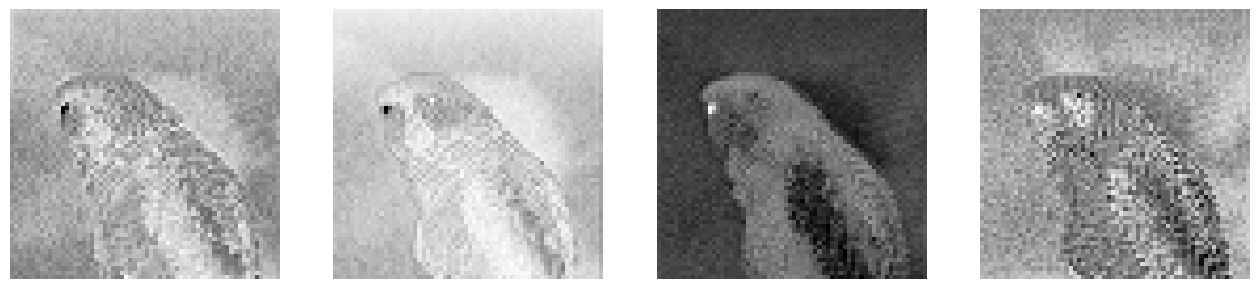

In [ ]:
buf = BytesIO()
img.save(buf, format='png')
buf.seek(0)
a, b = process(fbytes=buf.getvalue())

In [ ]:
a[:200], b[:200]

('iVBORw0KGgoAAAANSUhEUgAABkAAAAGQCAYAAAD2lawGAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAsqJJREFUeJztvXvwntdZnvuEHjgUEmM7',
 'iVBORw0KGgoAAAANSUhEUgAAAgAAAAIACAIAAAB7GkOtAAEAAElEQVR4nKz9Sbdlu44uhn0f5toRcc65WTy9J0vDsp6b6tn//6e442F37DGeLOWtThGxFwE3QIBgMdfeN1Mz88ZZe04WIIiKIAjy//a//N8BACBJEuVZ3uTvpVi+MbO9lpmJiKrW6lkS98/Staqamb9c')

### Upload Route

In [ ]:
from base64 import b64encode
from io import BytesIO
from PIL import Image
@rt
async def upload(file:UploadFile, vae_scale:float, norm_one:float, norm_two:float): 
    try:
        fbytes = await file.read()
        lat_b64, proc_b64 = process(fbytes, vae_scale, norm_one, norm_two)
        return Div(style="display:flex; flex-direction:column")(
            Img(src=f'data:image/jpeg;base64,{lat_b64}', style='max-width:800px; width: 100%'),
            Img(src=f'data:image/jpeg;base64,{proc_b64}', style='max-width:800px; width: 50%; display:block; margin:auto'),
        )
    except Exception as e: return Article(f"{t('error_msg')}{e}", style="color: var(--pico-del-color); border-color: var(--pico-del-color);")

In [ ]:
from starlette.datastructures import UploadFile
buf.seek(0)
uf = UploadFile(file=buf); uf

UploadFile(filename=None, size=None, headers=Headers({}))

In [ ]:
# 
# await upload(uf, 0.18215, 2, 1)

### Dashboard

In [ ]:
import fasthtml.components as fc
@delegates(fc.Input)
def LabelledInput(lbl=None, tip=None, id=None, name=None, **kwargs): 
    assert id is not None or name is not None, "id or name required"
    return Div(style='flex-direction:column')(
        fc.Label(lbl, data_tooltip=tip, fr=f'inp-{id or name}', id=f'lbl-{id or name}'), 
        fc.Input(id=f'inp-{id or name}', name=name, **kwargs)
    )

I've overwritten `Input` so it always has a `Label` component attached to it.

In [ ]:
p(LabelledInput(placeholder='hehe', name='testing', tip='LOL', lbl='haha'))

HTML(<iframe srcdoc="&lt;!doctype html&gt;
&lt;html&gt;
  &lt;head&gt;
    &lt;title&gt;FastHTML page&lt;/title&gt;
    &lt;link rel=&quot;canonical&quot; href=&quot;https://testserver/_IKD1OAR6Sl2gdxYVHs_X6w&quot;&gt;
    &lt;meta charset=&quot;utf-8&quot;&gt;
    &lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1, viewport-fit=cover&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/npm/htmx.org@2.0.7/dist/htmx.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/fasthtml-js@1.0.12/fasthtml.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/surreal@main/surreal.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/gnat/css-scope-inline@main/script.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/npm/@picocss/pico@latest/css/pico.min.css&quot;&gt;
    &lt;style&gt;:root { --pico-font-size: 100%; }&lt;/style&gt;
&lt;script type=&quot;module&quot;&gt;import { marked } from &quot;https://cdn.jsdelivr.net/npm/marked/lib/marked.esm.js&quot;;
proc_htmx(&#x27;.marked&#x27;, e =&gt; e.innerHTML = marked.parse(e.textContent));&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-dark.css&quot; media=&quot;(prefers-color-scheme: dark)&quot;&gt;
    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-light.css&quot; media=&quot;(prefers-color-scheme: light)&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/highlight.min.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.css&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/languages/python.min.js&quot;&gt;&lt;/script&gt;&lt;script type=&quot;module&quot;&gt;
hljs.addPlugin(new CopyButtonPlugin());
hljs.configure({&#x27;cssSelector&#x27;: &#x27;pre code:not([data-highlighted=&quot;yes&quot;])&#x27;});
htmx.onLoad(hljs.highlightAll);&lt;/script&gt;&lt;script&gt;
    function sendmsg() {
        window.parent.postMessage({height: document.documentElement.offsetHeight}, &#x27;*&#x27;);
    }
    window.onload = function() {
        sendmsg();
        document.body.addEventListener(&#x27;htmx:afterSettle&#x27;,    sendmsg);
        document.body.addEventListener(&#x27;htmx:wsAfterMessage&#x27;, sendmsg);
    };&lt;/script&gt;  &lt;/head&gt;
  &lt;body&gt;
    &lt;div style=&quot;flex-direction:column&quot;&gt;
&lt;label data-tooltip=&quot;LOL&quot; for=&quot;inp-testing&quot; id=&quot;lbl-testing&quot;&gt;haha&lt;/label&gt;      &lt;input name=&quot;testing&quot; placeholder=&quot;hehe&quot; id=&quot;inp-testing&quot;&gt;
    &lt;/div&gt;
  &lt;/body&gt;
&lt;/html&gt;
" style="width: 100%; height: auto; border: none;" onload="{
        let frame = this;
        window.addEventListener('message', function(e) {
            if (e.source !== frame.contentWindow) return; // Only proceed if the message is from this iframe
            if (e.data.height) frame.style.height = (e.data.height+1) + 'px';
        }, false);
    }" allow="accelerometer; autoplay; camera; clipboard-read; clipboard-write; display-capture; encrypted-media; fullscreen; gamepad; geolocation; gyroscope; hid; identity-credentials-get; idle-detection; magnetometer; microphone; midi; payment; picture-in-picture; publickey-credentials-get; screen-wake-lock; serial; usb; web-share; xr-spatial-tracking"></iframe> )

In [ ]:
def Dashboard():
    return Card(style='flex:2')(
        Form(hx_post=upload, hx_target='#res', hx_swap='innerHTML',
             hx_indicator='#loading', hx_disabled_elt='#process-btn, #upload-inp',
             enctype="multipart/form-data")(
            UploadWidget(),
            Div(style='margin-top: 1rem')(SettingsWidget()),
        )
    )

In [ ]:
def UploadWidget():
    return Div(style='display:flex; align-items:center; gap:0.5rem')(
        UploadInput(t('image_label'), name='file'),
        Button(t('process'), type='submit', id='process-btn', style='margin-bottom:0;'),
    )

In [ ]:
@delegates(fc.Input)
def UploadInput(lbl=None, id=None, name=None, **kwargs): 
    assert id is not None or name is not None, "id or name required"
    return Div()(
        fc.Label(style='margin-bottom:0', role='button')(lbl, id=f"lbl-{id or name}", fr=f"inp-{id or name}"),
        fc.Input(id=f"inp-{id or name}", name=name, type='file', accept='image/*', style='display:none; margin-bottom:0', onchange="this.previousElementSibling.style.backgroundColor = this.files[0] ? 'green' : ''", **kwargs),
    )

In [ ]:
p(UploadInput('test', id='test'))

HTML(<iframe srcdoc="&lt;!doctype html&gt;
&lt;html&gt;
  &lt;head&gt;
    &lt;title&gt;FastHTML page&lt;/title&gt;
    &lt;link rel=&quot;canonical&quot; href=&quot;https://testserver/_F3oBoADXTfCOXtoI8l6eBQ&quot;&gt;
    &lt;meta charset=&quot;utf-8&quot;&gt;
    &lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1, viewport-fit=cover&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/npm/htmx.org@2.0.7/dist/htmx.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/fasthtml-js@1.0.12/fasthtml.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/surreal@main/surreal.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/gnat/css-scope-inline@main/script.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/npm/@picocss/pico@latest/css/pico.min.css&quot;&gt;
    &lt;style&gt;:root { --pico-font-size: 100%; }&lt;/style&gt;
&lt;script type=&quot;module&quot;&gt;import { marked } from &quot;https://cdn.jsdelivr.net/npm/marked/lib/marked.esm.js&quot;;
proc_htmx(&#x27;.marked&#x27;, e =&gt; e.innerHTML = marked.parse(e.textContent));&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-dark.css&quot; media=&quot;(prefers-color-scheme: dark)&quot;&gt;
    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-light.css&quot; media=&quot;(prefers-color-scheme: light)&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/highlight.min.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.css&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/languages/python.min.js&quot;&gt;&lt;/script&gt;&lt;script type=&quot;module&quot;&gt;
hljs.addPlugin(new CopyButtonPlugin());
hljs.configure({&#x27;cssSelector&#x27;: &#x27;pre code:not([data-highlighted=&quot;yes&quot;])&#x27;});
htmx.onLoad(hljs.highlightAll);&lt;/script&gt;&lt;script&gt;
    function sendmsg() {
        window.parent.postMessage({height: document.documentElement.offsetHeight}, &#x27;*&#x27;);
    }
    window.onload = function() {
        sendmsg();
        document.body.addEventListener(&#x27;htmx:afterSettle&#x27;,    sendmsg);
        document.body.addEventListener(&#x27;htmx:wsAfterMessage&#x27;, sendmsg);
    };&lt;/script&gt;  &lt;/head&gt;
  &lt;body&gt;
    &lt;div&gt;
&lt;label role=&quot;button&quot; style=&quot;margin-bottom:0&quot; id=&quot;lbl-test&quot; for=&quot;inp-test&quot;&gt;test&lt;/label&gt;      &lt;input type=&quot;file&quot; accept=&quot;image/*&quot; onchange=&quot;this.previousElementSibling.style.backgroundColor = this.files[0] ? &#x27;green&#x27; : &#x27;&#x27;&quot; id=&quot;inp-test&quot; style=&quot;display:none; margin-bottom:0&quot; name=&quot;inp-test&quot;&gt;
    &lt;/div&gt;
  &lt;/body&gt;
&lt;/html&gt;
" style="width: 100%; height: auto; border: none;" onload="{
        let frame = this;
        window.addEventListener('message', function(e) {
            if (e.source !== frame.contentWindow) return; // Only proceed if the message is from this iframe
            if (e.data.height) frame.style.height = (e.data.height+1) + 'px';
        }, false);
    }" allow="accelerometer; autoplay; camera; clipboard-read; clipboard-write; display-capture; encrypted-media; fullscreen; gamepad; geolocation; gyroscope; hid; identity-credentials-get; idle-detection; magnetometer; microphone; midi; payment; picture-in-picture; publickey-credentials-get; screen-wake-lock; serial; usb; web-share; xr-spatial-tracking"></iframe> )

In [ ]:
p(UploadWidget())

HTML(<iframe srcdoc="&lt;!doctype html&gt;
&lt;html&gt;
  &lt;head&gt;
    &lt;title&gt;FastHTML page&lt;/title&gt;
    &lt;link rel=&quot;canonical&quot; href=&quot;https://testserver/_FyEny0VUT_Kx6di7XM-G0A&quot;&gt;
    &lt;meta charset=&quot;utf-8&quot;&gt;
    &lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1, viewport-fit=cover&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/npm/htmx.org@2.0.7/dist/htmx.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/fasthtml-js@1.0.12/fasthtml.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/surreal@main/surreal.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/gnat/css-scope-inline@main/script.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/npm/@picocss/pico@latest/css/pico.min.css&quot;&gt;
    &lt;style&gt;:root { --pico-font-size: 100%; }&lt;/style&gt;
&lt;script type=&quot;module&quot;&gt;import { marked } from &quot;https://cdn.jsdelivr.net/npm/marked/lib/marked.esm.js&quot;;
proc_htmx(&#x27;.marked&#x27;, e =&gt; e.innerHTML = marked.parse(e.textContent));&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-dark.css&quot; media=&quot;(prefers-color-scheme: dark)&quot;&gt;
    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-light.css&quot; media=&quot;(prefers-color-scheme: light)&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/highlight.min.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.css&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/languages/python.min.js&quot;&gt;&lt;/script&gt;&lt;script type=&quot;module&quot;&gt;
hljs.addPlugin(new CopyButtonPlugin());
hljs.configure({&#x27;cssSelector&#x27;: &#x27;pre code:not([data-highlighted=&quot;yes&quot;])&#x27;});
htmx.onLoad(hljs.highlightAll);&lt;/script&gt;&lt;script&gt;
    function sendmsg() {
        window.parent.postMessage({height: document.documentElement.offsetHeight}, &#x27;*&#x27;);
    }
    window.onload = function() {
        sendmsg();
        document.body.addEventListener(&#x27;htmx:afterSettle&#x27;,    sendmsg);
        document.body.addEventListener(&#x27;htmx:wsAfterMessage&#x27;, sendmsg);
    };&lt;/script&gt;  &lt;/head&gt;
  &lt;body&gt;
    &lt;div style=&quot;display:flex; align-items:center; gap:0.5rem&quot;&gt;
      &lt;div&gt;
&lt;label role=&quot;button&quot; style=&quot;margin-bottom:0&quot; id=&quot;lbl-file&quot; for=&quot;inp-file&quot;&gt;图片&lt;/label&gt;        &lt;input name=&quot;file&quot; type=&quot;file&quot; accept=&quot;image/*&quot; onchange=&quot;this.previousElementSibling.style.backgroundColor = this.files[0] ? &#x27;green&#x27; : &#x27;&#x27;&quot; id=&quot;inp-file&quot; style=&quot;display:none; margin-bottom:0&quot;&gt;
      &lt;/div&gt;
&lt;button type=&quot;submit&quot; id=&quot;process-btn&quot; style=&quot;margin-bottom:0;&quot; name=&quot;process-btn&quot;&gt;开始处理&lt;/button&gt;    &lt;/div&gt;
  &lt;/body&gt;
&lt;/html&gt;
" style="width: 100%; height: auto; border: none;" onload="{
        let frame = this;
        window.addEventListener('message', function(e) {
            if (e.source !== frame.contentWindow) return; // Only proceed if the message is from this iframe
            if (e.data.height) frame.style.height = (e.data.height+1) + 'px';
        }, false);
    }" allow="accelerometer; autoplay; camera; clipboard-read; clipboard-write; display-capture; encrypted-media; fullscreen; gamep

In [ ]:
def SettingsWidget():
    return Details(
        Summary(t('advanced_settings'), id='adv-summary'),
        Div(style='display:flex; gap:1rem;')(
            LabelledInput(type='number', name='vae_scale', value=0.18215, step='any',
                lbl=t('vae_scale_label'), tip=t('vae_scale_tip')),
            LabelledInput(type='number', name='norm_one', value=2,
                lbl=t('norm_one_label'), tip=t('norm_tip')),
            LabelledInput(type='number', name='norm_two', value=1,
                lbl=t('norm_two_label'), tip=t('norm_tip')),
        ),
        P(t('vae_scale_desc'), id='vae-scale-desc'),
        P(t('norm_desc'), id='norm-desc')
    )

In [ ]:
p(SettingsWidget())

HTML(<iframe srcdoc="&lt;!doctype html&gt;
&lt;html&gt;
  &lt;head&gt;
    &lt;title&gt;FastHTML page&lt;/title&gt;
    &lt;link rel=&quot;canonical&quot; href=&quot;https://testserver/_HtsGzo_LTWSVDU8DKRzN2A&quot;&gt;
    &lt;meta charset=&quot;utf-8&quot;&gt;
    &lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1, viewport-fit=cover&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/npm/htmx.org@2.0.7/dist/htmx.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/fasthtml-js@1.0.12/fasthtml.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/surreal@main/surreal.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/gnat/css-scope-inline@main/script.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/npm/@picocss/pico@latest/css/pico.min.css&quot;&gt;
    &lt;style&gt;:root { --pico-font-size: 100%; }&lt;/style&gt;
&lt;script type=&quot;module&quot;&gt;import { marked } from &quot;https://cdn.jsdelivr.net/npm/marked/lib/marked.esm.js&quot;;
proc_htmx(&#x27;.marked&#x27;, e =&gt; e.innerHTML = marked.parse(e.textContent));&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-dark.css&quot; media=&quot;(prefers-color-scheme: dark)&quot;&gt;
    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-light.css&quot; media=&quot;(prefers-color-scheme: light)&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/highlight.min.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.css&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/languages/python.min.js&quot;&gt;&lt;/script&gt;&lt;script type=&quot;module&quot;&gt;
hljs.addPlugin(new CopyButtonPlugin());
hljs.configure({&#x27;cssSelector&#x27;: &#x27;pre code:not([data-highlighted=&quot;yes&quot;])&#x27;});
htmx.onLoad(hljs.highlightAll);&lt;/script&gt;&lt;script&gt;
    function sendmsg() {
        window.parent.postMessage({height: document.documentElement.offsetHeight}, &#x27;*&#x27;);
    }
    window.onload = function() {
        sendmsg();
        document.body.addEventListener(&#x27;htmx:afterSettle&#x27;,    sendmsg);
        document.body.addEventListener(&#x27;htmx:wsAfterMessage&#x27;, sendmsg);
    };&lt;/script&gt;  &lt;/head&gt;
  &lt;body&gt;
&lt;details&gt;&lt;summary id=&quot;adv-summary&quot;&gt;高级设置&lt;/summary&gt;      &lt;div style=&quot;display:flex; gap:1rem;&quot;&gt;
        &lt;div style=&quot;flex-direction:column&quot;&gt;
&lt;label data-tooltip=&quot;归一化潜在空间，匹配噪声调度器的尺度&quot; for=&quot;inp-vae_scale&quot; id=&quot;lbl-vae_scale&quot;&gt;VAE 缩放&lt;/label&gt;          &lt;input name=&quot;vae_scale&quot; type=&quot;number&quot; value=&quot;0.18215&quot; step=&quot;any&quot; id=&quot;inp-vae_scale&quot;&gt;
        &lt;/div&gt;
        &lt;div style=&quot;flex-direction:column&quot;&gt;
&lt;label data-tooltip=&quot;将像素值从 [0,1] 映射到 [-1,1]，匹配 VAE 训练分布&quot; for=&quot;inp-norm_one&quot; id=&quot;lbl-norm_one&quot;&gt;归一化因子1&lt;/label&gt;          &lt;input name=&quot;norm_one&quot; type=&quot;number&quot; value=&quot;2&quot; id=&quot;inp-norm_one&quot;&gt;
        &lt;/div&gt;
        &lt;div style=&quot;flex-direction:column&quot;&gt;
&lt;label data-tooltip=&quot;将像素值从 [0,1] 映射到 [-1,1]，匹配 VAE 训练分布&quot; for=&quot;inp-norm_two&quot; id=&quot;lbl-norm_two&quot;&gt;归一化因子2&lt;/label&gt;          &lt;input name=&quot;norm_two&quot; type=&quot;number&quot; value=&quot;1&quot; id=&quot;inp-norm_two&quot;&gt;
        &lt;/div&gt;
    

In [ ]:
p(Dashboard())

HTML(<iframe srcdoc="&lt;!doctype html&gt;
&lt;html&gt;
  &lt;head&gt;
    &lt;title&gt;FastHTML page&lt;/title&gt;
    &lt;link rel=&quot;canonical&quot; href=&quot;https://testserver/_w5fJstg7RxCL_iKSg2xXrQ&quot;&gt;
    &lt;meta charset=&quot;utf-8&quot;&gt;
    &lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1, viewport-fit=cover&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/npm/htmx.org@2.0.7/dist/htmx.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/fasthtml-js@1.0.12/fasthtml.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/answerdotai/surreal@main/surreal.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/gnat/css-scope-inline@main/script.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/npm/@picocss/pico@latest/css/pico.min.css&quot;&gt;
    &lt;style&gt;:root { --pico-font-size: 100%; }&lt;/style&gt;
&lt;script type=&quot;module&quot;&gt;import { marked } from &quot;https://cdn.jsdelivr.net/npm/marked/lib/marked.esm.js&quot;;
proc_htmx(&#x27;.marked&#x27;, e =&gt; e.innerHTML = marked.parse(e.textContent));&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-dark.css&quot; media=&quot;(prefers-color-scheme: dark)&quot;&gt;
    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/styles/atom-one-light.css&quot; media=&quot;(prefers-color-scheme: light)&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/highlight.min.js&quot;&gt;&lt;/script&gt;&lt;script src=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.js&quot;&gt;&lt;/script&gt;    &lt;link rel=&quot;stylesheet&quot; href=&quot;https://cdn.jsdelivr.net/gh/arronhunt/highlightjs-copy/dist/highlightjs-copy.min.css&quot;&gt;
&lt;script src=&quot;https://cdn.jsdelivr.net/gh/highlightjs/cdn-release/build/languages/python.min.js&quot;&gt;&lt;/script&gt;&lt;script type=&quot;module&quot;&gt;
hljs.addPlugin(new CopyButtonPlugin());
hljs.configure({&#x27;cssSelector&#x27;: &#x27;pre code:not([data-highlighted=&quot;yes&quot;])&#x27;});
htmx.onLoad(hljs.highlightAll);&lt;/script&gt;&lt;script&gt;
    function sendmsg() {
        window.parent.postMessage({height: document.documentElement.offsetHeight}, &#x27;*&#x27;);
    }
    window.onload = function() {
        sendmsg();
        document.body.addEventListener(&#x27;htmx:afterSettle&#x27;,    sendmsg);
        document.body.addEventListener(&#x27;htmx:wsAfterMessage&#x27;, sendmsg);
    };&lt;/script&gt;  &lt;/head&gt;
  &lt;body&gt;
    &lt;article style=&quot;flex:2&quot;&gt;
&lt;form enctype=&quot;multipart/form-data&quot; hx-post=&quot;/upload&quot; hx-swap=&quot;innerHTML&quot; hx-indicator=&quot;#loading&quot; hx-disabled-elt=&quot;#process-btn, #upload-inp&quot; hx-target=&quot;#res&quot;&gt;        &lt;div style=&quot;display:flex; align-items:center; gap:0.5rem&quot;&gt;
          &lt;div&gt;
&lt;label role=&quot;button&quot; style=&quot;margin-bottom:0&quot; id=&quot;lbl-file&quot; for=&quot;inp-file&quot;&gt;图片&lt;/label&gt;            &lt;input name=&quot;file&quot; type=&quot;file&quot; accept=&quot;image/*&quot; onchange=&quot;this.previousElementSibling.style.backgroundColor = this.files[0] ? &#x27;green&#x27; : &#x27;&#x27;&quot; id=&quot;inp-file&quot; style=&quot;display:none; margin-bottom:0&quot;&gt;
          &lt;/div&gt;
&lt;button type=&quot;submit&quot; id=&quot;process-btn&quot; style=&quot;margin-bottom:0;&quot; name=&quot;process-btn&quot;&gt;开始处理&lt;/button&gt;        &lt;/div&gt;
        &lt;div style=&quot;margin-top: 1rem&quot;&gt;
&lt;details&gt;&lt;summary id=&quot;adv-summary&quot;&gt;高级设置&lt;/summary&gt;            &lt;div style=&quot;display:flex; gap:1rem;&quot;&gt;
              &lt;div s

### Main

I'll first define route that'll toggle language, before writing the index page.

In [ ]:
@rt
def toggle_lang(session):
    lang = 'en' if session.get('lang') == 'zh' else 'zh'
    current_lang.set(lang)
    session['lang'] = lang
    return (
        Button(t('process'), type='submit', id='process-btn', hx_swap_oob='true', style='margin-bottom:0'),
        H1(t('title'), id='title', hx_swap_oob='true'),
        Summary(t('advanced_settings'), id='adv-summary', hx_swap_oob='true'),
        Div(id='res', style='display:flex; align-items:center; justify-content:center; flex:1', hx_swap_oob='true')(t('no_result')),
        Label(t('image_label'), id='lbl-file', fr='inp-file', role='button', hx_swap_oob='true', style='margin-bottom:0'),
        Label(t('vae_scale_label'), id='lbl-vae_scale', fr='vae_scale', hx_swap_oob='true', data_tooltip=t('vae_scale_tip')),
        Label(t('norm_one_label'), id='lbl-norm_one', fr='norm_one', hx_swap_oob='true', data_tooltip=t('norm_tip')),
        Label(t('norm_two_label'), id='lbl-norm_two', fr='norm_two', hx_swap_oob='true', data_tooltip=t('norm_tip')),
        P(t('vae_scale_desc'), id='vae-scale-desc', hx_swap_oob='true'),
        P(t('norm_desc'), id='norm-desc', hx_swap_oob='true'),
        Footer(id='footer', hx_swap_oob='true', style='color: var(--pico-muted-color);')(t('footer'), A('FastHTML', href='https://fastht.ml'), t('crafted_by'), A(t('name'), href='https://forbo7.github.io/'))
    )

In [ ]:
@rt
def index(session): 
    setsession(session)
    return Card(style="padding: 2rem; max-width: 1200px; margin: 2rem auto;")(
        Div(style="display:flex; align-items:center; gap:1rem; margin-bottom:2rem")(
            H1(t('title'), id='title'),
            Button('🌐', hx_post=toggle_lang, hx_swap='none'),
            Div(id='loading', aria_busy='true', cls='htmx-indicator')(''),
        ),
        Div(style="display:flex; gap:1rem; align-items:stretch")(
            Dashboard(),
            Card(style='flex:3; margin-top:1rem; display:flex; flex-direction:column; align-items:center; min-height: 200px;')(
                Div(id='res', style='display:flex; align-items:center; justify-content:center; flex:1')(t('no_result')),
            )
        ),
        Footer(id='footer', style='color: var(--pico-muted-color);')(t('footer'), A('FastHTML', href='https://fastht.ml'), t('crafted_by'), A(t('name'), href='https://forbo7.github.io/'))
    )

prev(index)

HTML(<iframe src="https://the-vae-visualizer.solveit.pub:443/" style="width: 100%; height: auto; border: none;" onload="{
        let frame = this;
        window.addEventListener('message', function(e) {
            if (e.source !== frame.contentWindow) return; // Only proceed if the message is from this iframe
            if (e.data.height) frame.style.height = (e.data.height+1) + 'px';
        }, false);
    }" allow="accelerometer; autoplay; camera; clipboard-read; clipboard-write; display-capture; encrypted-media; fullscreen; gamepad; geolocation; gyroscope; hid; identity-credentials-get; idle-detection; magnetometer; microphone; midi; payment; picture-in-picture; publickey-credentials-get; screen-wake-lock; serial; usb; web-share; xr-spatial-tracking"></iframe> )

---

If you have any comments, questions, suggestions, feedback, criticisms, or corrections, please do post them down in the comment section below!